# Aprendizagem de Máquina — Random Forest & XGBoost

Notebook de ML para os dois experimentos da tese (base sem RIN e base com RIN).

## Protocolo (conforme Seção 3.2.3 da tese)
- **RandomizedSearchCV** com `StratifiedKFold(n_splits=10, shuffle=True, random_state=15)`
- `n_iter=100`, `random_state=np.random.RandomState(0)`, `refit='Accuracy'`, `n_jobs=-1`
- Busca realizada **somente no treino** — teste nunca é visto até a avaliação final
- **Métricas finais** calculadas na base de teste: Acc., TNR, NPV, TPR, PPV, F1-score, ROC-AUC

## Estrutura
1. [Configurações e carga das bases](#scrollTo=aa955a09)
2. [Funções auxiliares](#scrollTo=8b0ecbc4) (avaliação, gráficos)
3. [Experimento 1 — Base **SEM RIN**](#scrollTo=bd633c08) (RandomForest + XGBoost)
4. [Experimento 2 — Base **COM RIN**](#scrollTo=dde2aaf2) (RandomForest + XGBoost)
5. [Comparação geral](#scrollTo=d84289e5)


# 1. Configurações e Carga das Bases

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install -q xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from scipy.stats import randint, uniform

sns.set_theme(style='whitegrid', palette='Set2')

# ── Configurações globais (conforme tese) ─────────────────────────────────────
SEED        = np.random.RandomState(0)   # semente global — tese Seção 3.2.3
CV_SEED     = 15                         # random_state do StratifiedKFold
N_SPLITS    = 10                         # K=10 — tese Seção 3.2.3
N_ITER      = 100                        # n_iter — tese Tabela 20
REFIT       = 'Accuracy'                 # critério de re-fit — tese Tabela 20
ROTULO      = 'Deleteria11'
DATA_DIR    = '/content/drive/MyDrive/Bioinfo/Bases'

print('Imports OK')
print(f'  RandomizedSearchCV: n_iter={N_ITER}, cv={N_SPLITS}-fold, refit={REFIT!r}')


Imports OK
  RandomizedSearchCV: n_iter=100, cv=10-fold, refit='Accuracy'


In [3]:
CAMINHO_CSV_train_com = '/content/drive/MyDrive/Bioinfo/Bases/train_com_rin.csv'
CAMINHO_CSV_teste_com = '/content/drive/MyDrive/Bioinfo/Bases/test_com_rin.csv'
CAMINHO_CSV_train_sem = '/content/drive/MyDrive/Bioinfo/Bases/train_sem_rin.csv'
CAMINHO_CSV_teste_sem = '/content/drive/MyDrive/Bioinfo/Bases/test_sem_rin.csv'

train_sem = pd.read_csv(CAMINHO_CSV_train_sem, sep='\t')
test_sem  = pd.read_csv(CAMINHO_CSV_teste_sem, sep='\t')
train_com = pd.read_csv(CAMINHO_CSV_train_com, sep='\t')
test_com  = pd.read_csv(CAMINHO_CSV_teste_com, sep='\t')

print('Bases carregadas')


Bases carregadas


In [4]:
# ── Carga das bases (geradas pelo notebook de pré-processamento V4) ───────────
X_train_sem = train_sem.drop(columns=[ROTULO])
y_train_sem = train_sem[ROTULO]
X_test_sem  = test_sem.drop(columns=[ROTULO])
y_test_sem  = test_sem[ROTULO]

X_train_com = train_com.drop(columns=[ROTULO])
y_train_com = train_com[ROTULO]
X_test_com  = test_com.drop(columns=[ROTULO])
y_test_com  = test_com[ROTULO]

print('\nBases após remoção:')
print(f'  SEM RIN — treino: {X_train_sem.shape}  |  teste: {X_test_sem.shape}')
print(f'  COM RIN — treino: {X_train_com.shape}  |  teste: {X_test_com.shape}')



Bases após remoção:
  SEM RIN — treino: (708, 20)  |  teste: (179, 20)
  COM RIN — treino: (646, 31)  |  teste: (179, 31)


# 2. Funções Auxiliares

In [5]:
def avaliar_modelo(nome, modelo, X_test, y_test):
    """
    Calcula todas as métricas da tese (Seção 2.7) na base de teste.
    Retorna um dict com Acc, TNR, NPV, TPR, PPV, F1, ROC-AUC.
    """
    y_pred  = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    acc     = (tp + tn) / (tp + tn + fp + fn)
    tpr     = tp / (tp + fn)          # Sensibilidade / Recall
    tnr     = tn / (tn + fp)          # Especificidade
    ppv     = tp / (tp + fp)          # Precisão
    npv     = tn / (tn + fn)          # Valor Pred. Negativo
    f1      = 2 * ppv * tpr / (ppv + tpr)
    auc     = roc_auc_score(y_test, y_proba)

    return {
        'Modelo'   : nome,
        'Acc. (%)'  : round(acc * 100, 2),
        'TNR (%)'   : round(tnr * 100, 2),
        'NPV (%)'   : round(npv * 100, 2),
        'TPR (%)'   : round(tpr * 100, 2),
        'PPV (%)'   : round(ppv * 100, 2),
        'ROC-AUC'   : round(auc, 4),
        'F1-Score (%)': round(f1 * 100, 2),
        '_y_pred'   : y_pred,
        '_y_proba'  : y_proba,
    }


def plot_resultados(resultados, X_test, y_test, titulo):
    """
    Plota matriz de confusão + curva ROC para cada modelo.
    """
    n = len(resultados)
    fig, axes = plt.subplots(2, n, figsize=(7 * n, 12))
    if n == 1:
        axes = axes.reshape(2, 1)

    cores_roc = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    for i, res in enumerate(resultados):
        nome    = res['Modelo']
        y_pred  = res['_y_pred']
        y_proba = res['_y_proba']

        # ── Matriz de confusão ─────────────────────────────────────────────
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(
            cm,
            display_labels=['Benigna (0)', 'Patogênica (1)']
        )
        disp.plot(ax=axes[0, i], colorbar=False, cmap='Blues')
        axes[0, i].set_title(
            f'{nome}\nAcc={res["Acc. (%)"]:.2f}%  AUC={res["ROC-AUC"]:.4f}',
            fontsize=11, fontweight='bold'
        )

        # ── Curva ROC ──────────────────────────────────────────────────────
        fpr, tpr_vals, _ = roc_curve(y_test, y_proba)
        axes[1, i].plot(
            fpr, tpr_vals,
            color=cores_roc[i % len(cores_roc)], lw=2,
            label=f'AUC = {res["ROC-AUC"]:.4f}'
        )
        axes[1, i].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6)
        axes[1, i].set_xlabel('Taxa de Falso Positivo (FPR)')
        axes[1, i].set_ylabel('Taxa de Verdadeiro Positivo (TPR)')
        axes[1, i].set_title(f'Curva ROC — {nome}', fontweight='bold')
        axes[1, i].legend(loc='lower right')
        axes[1, i].set_xlim([0, 1])
        axes[1, i].set_ylim([0, 1])

    plt.suptitle(titulo, fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


def tabela_metricas(resultados):
    """Exibe tabela formatada com as métricas (sem colunas internas _y_*)."""
    cols = ['Modelo', 'Acc. (%)', 'TNR (%)', 'NPV (%)',
            'TPR (%)', 'PPV (%)', 'ROC-AUC', 'F1-Score (%)']
    df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')}
                        for r in resultados])[cols]
    return df.set_index('Modelo').style.highlight_max(
        axis=0, color='#d4edda'
    ).format(precision=2)


def plot_feature_importance(modelo, feature_names, titulo, top_n=20):
    """Importância dos atributos (Gini para RF, gain para XGB)."""
    importances = pd.Series(
        modelo.best_estimator_.feature_importances_,
        index=feature_names
    ).sort_values(ascending=True).tail(top_n)

    fig, ax = plt.subplots(figsize=(10, max(6, top_n * 0.4)))
    importances.plot(kind='barh', ax=ax, color='teal', edgecolor='white')
    ax.set_title(f'Importância dos Atributos (top {top_n}) — {titulo}',
                 fontweight='bold')
    ax.set_xlabel('Score de Importância')
    plt.tight_layout()
    plt.show()


print('Funções auxiliares definidas.')


Funções auxiliares definidas.


# 3. Experimento 1 — Base SEM RIN

Busca de hiperparâmetros com `RandomizedSearchCV` no treino.
Avaliação final na base de teste.


## 3.1 Random Forest — Sem RIN

In [6]:
# ── Espaço de busca ──────────────────────────────────────────────────────────
param_rf = {
    'n_estimators'      : randint(100, 600),
    'max_depth'         : [None, 5, 10, 15, 20, 30],
    'max_features'      : ['sqrt', 'log2', 0.3, 0.5],
    'min_samples_split' : randint(2, 20),
    'min_samples_leaf'  : randint(1, 10),
    'bootstrap'         : [True, False],
}

# ── Validação cruzada (tese: K=10, random_state=15) ──────────────────────────
cv_strat = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=CV_SEED)

# ── Scorer personalizado (Acc + AUC) — tese Tabela 20 ────────────────────────
from sklearn.metrics import make_scorer
scorers = {
    'Accuracy' : make_scorer(accuracy_score),
    'AUC'      : make_scorer(roc_auc_score, needs_proba=True),
}

# ── RandomizedSearchCV ────────────────────────────────────────────────────────
rf_sem = RandomizedSearchCV(
    estimator     = RandomForestClassifier(random_state=42),
    param_distributions = param_rf,
    n_iter        = N_ITER,
    cv            = cv_strat,
    scoring       = scorers,
    refit         = REFIT,
    return_train_score = True,
    n_jobs        = -1,
    random_state  = SEED,
    verbose       = 1,
)

rf_sem.fit(X_train_sem, y_train_sem)

print('\n── Melhores Hiperparâmetros (Random Forest | sem RIN) ──')
for k, v in rf_sem.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nMelhor Accuracy (CV treino): {rf_sem.best_score_:.4f}')


Fitting 10 folds for each of 100 candidates, totalling 1000 fits

── Melhores Hiperparâmetros (Random Forest | sem RIN) ──
  bootstrap: True
  max_depth: 5
  max_features: sqrt
  min_samples_leaf: 4
  min_samples_split: 8
  n_estimators: 309

Melhor Accuracy (CV treino): 0.6370


In [7]:
# ── Avaliação na base de teste ────────────────────────────────────────────────
res_rf_sem = avaliar_modelo('RF — sem RIN', rf_sem, X_test_sem, y_test_sem)
print('── Métricas na base de TESTE (Random Forest | sem RIN) ──')
for k, v in res_rf_sem.items():
    if not k.startswith('_'):
        print(f'  {k}: {v}')


── Métricas na base de TESTE (Random Forest | sem RIN) ──
  Modelo: RF — sem RIN
  Acc. (%): 67.6
  TNR (%): 66.28
  NPV (%): 66.28
  TPR (%): 68.82
  PPV (%): 68.82
  ROC-AUC: 0.7749
  F1-Score (%): 68.82


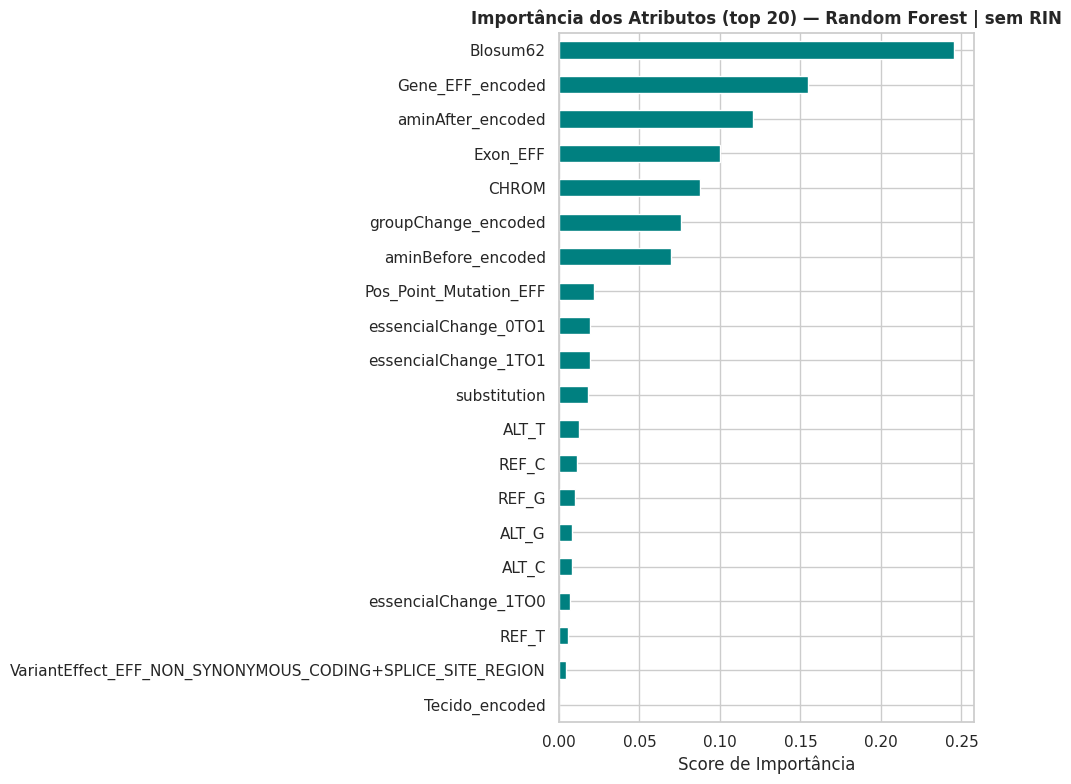

In [8]:
plot_feature_importance(rf_sem, X_train_sem.columns, 'Random Forest | sem RIN', top_n=20)


## 3.2 XGBoost — Sem RIN

In [9]:
# ── Espaço de busca ──────────────────────────────────────────────────────────
param_xgb = {
    'n_estimators'      : randint(100, 600),
    'max_depth'         : randint(3, 15),
    'learning_rate'     : uniform(0.01, 0.3),
    'subsample'         : uniform(0.6, 0.4),
    'colsample_bytree'  : uniform(0.4, 0.6),
    'min_child_weight'  : randint(1, 10),
    'gamma'             : uniform(0, 0.5),
    'reg_alpha'         : uniform(0, 1),
    'reg_lambda'        : uniform(0.5, 2),
}

xgb_sem = RandomizedSearchCV(
    estimator     = XGBClassifier(
        eval_metric  = 'logloss',
        use_label_encoder = False,
        random_state = 42,
        verbosity    = 0,
    ),
    param_distributions = param_xgb,
    n_iter        = N_ITER,
    cv            = cv_strat,
    scoring       = scorers,
    refit         = REFIT,
    return_train_score = True,
    n_jobs        = -1,
    random_state  = SEED,
    verbose       = 1,
)

xgb_sem.fit(X_train_sem, y_train_sem)

print('\n── Melhores Hiperparâmetros (XGBoost | sem RIN) ──')
for k, v in xgb_sem.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nMelhor Accuracy (CV treino): {xgb_sem.best_score_:.4f}')


Fitting 10 folds for each of 100 candidates, totalling 1000 fits

── Melhores Hiperparâmetros (XGBoost | sem RIN) ──
  colsample_bytree: 0.5638053407763428
  gamma: 0.4850375369255004
  learning_rate: 0.01764920469018845
  max_depth: 5
  min_child_weight: 9
  n_estimators: 139
  reg_alpha: 0.2777736736315105
  reg_lambda: 2.2897263843561775
  subsample: 0.6106090210395902

Melhor Accuracy (CV treino): 0.6314


In [10]:
res_xgb_sem = avaliar_modelo('XGB — sem RIN', xgb_sem, X_test_sem, y_test_sem)
print('── Métricas na base de TESTE (XGBoost | sem RIN) ──')
for k, v in res_xgb_sem.items():
    if not k.startswith('_'):
        print(f'  {k}: {v}')


── Métricas na base de TESTE (XGBoost | sem RIN) ──
  Modelo: XGB — sem RIN
  Acc. (%): 63.13
  TNR (%): 63.95
  NPV (%): 61.11
  TPR (%): 62.37
  PPV (%): 65.17
  ROC-AUC: 0.7404
  F1-Score (%): 63.74


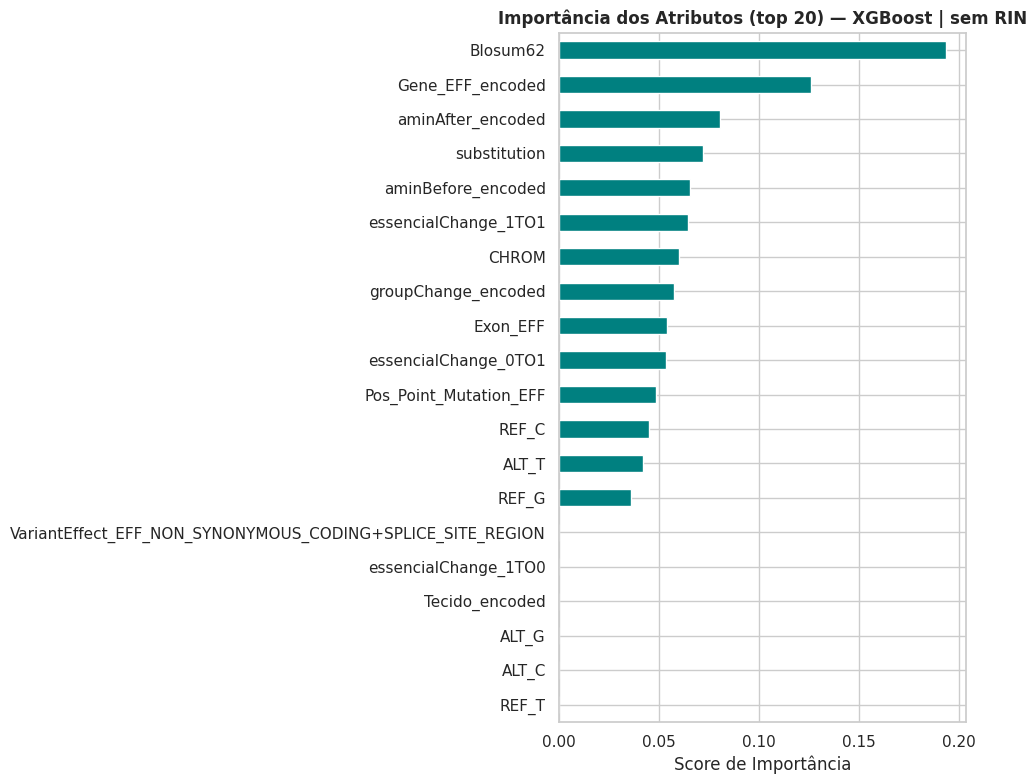

In [11]:
plot_feature_importance(xgb_sem, X_train_sem.columns, 'XGBoost | sem RIN', top_n=20)


## 3.3 Resultados Consolidados — Sem RIN

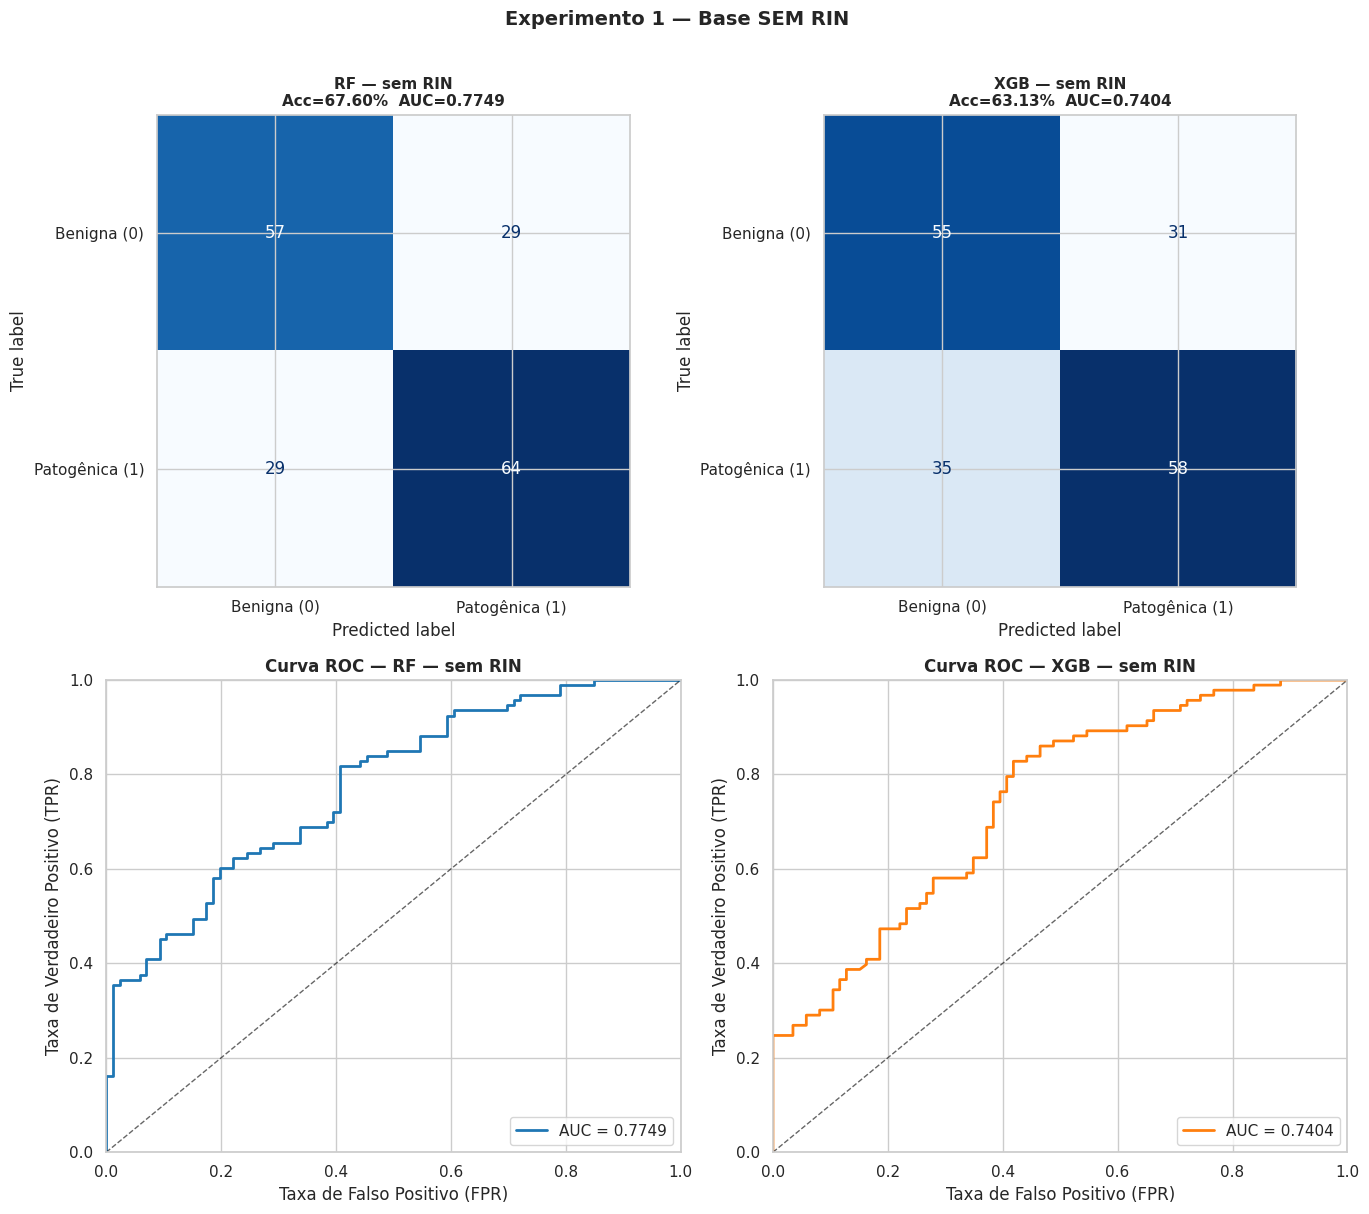


── Tabela de Métricas — Experimento 1 (SEM RIN) ──


,Acc. (%),TNR (%),NPV (%),TPR (%),PPV (%),ROC-AUC,F1-Score (%)
Modelo,,,,,,,
RF — sem RIN,67.60,66.28,66.28,68.82,68.82,0.77,68.82
XGB — sem RIN,63.13,63.95,61.11,62.37,65.17,0.74,63.74


In [12]:
resultados_sem = [res_rf_sem, res_xgb_sem]

plot_resultados(
    resultados_sem,
    X_test_sem, y_test_sem,
    'Experimento 1 — Base SEM RIN'
)

print('\n── Tabela de Métricas — Experimento 1 (SEM RIN) ──')
display(tabela_metricas(resultados_sem))


# 4. Experimento 2 — Base COM RIN

Mesmo protocolo do Experimento 1, agora com os atributos de RIN incluídos.


## 4.1 Random Forest — Com RIN

In [13]:
rf_com = RandomizedSearchCV(
    estimator     = RandomForestClassifier(random_state=42),
    param_distributions = param_rf,
    n_iter        = N_ITER,
    cv            = cv_strat,
    scoring       = scorers,
    refit         = REFIT,
    return_train_score = True,
    n_jobs        = -1,
    random_state  = SEED,
    verbose       = 1,
)

rf_com.fit(X_train_com, y_train_com)

print('\n── Melhores Hiperparâmetros (Random Forest | com RIN) ──')
for k, v in rf_com.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nMelhor Accuracy (CV treino): {rf_com.best_score_:.4f}')


Fitting 10 folds for each of 100 candidates, totalling 1000 fits

── Melhores Hiperparâmetros (Random Forest | com RIN) ──
  bootstrap: True
  max_depth: 5
  max_features: 0.3
  min_samples_leaf: 7
  min_samples_split: 14
  n_estimators: 428

Melhor Accuracy (CV treino): 0.6718


In [14]:
res_rf_com = avaliar_modelo('RF — com RIN', rf_com, X_test_com, y_test_com)
print('── Métricas na base de TESTE (Random Forest | com RIN) ──')
for k, v in res_rf_com.items():
    if not k.startswith('_'):
        print(f'  {k}: {v}')


── Métricas na base de TESTE (Random Forest | com RIN) ──
  Modelo: RF — com RIN
  Acc. (%): 66.48
  TNR (%): 70.93
  NPV (%): 63.54
  TPR (%): 62.37
  PPV (%): 69.88
  ROC-AUC: 0.7556
  F1-Score (%): 65.91


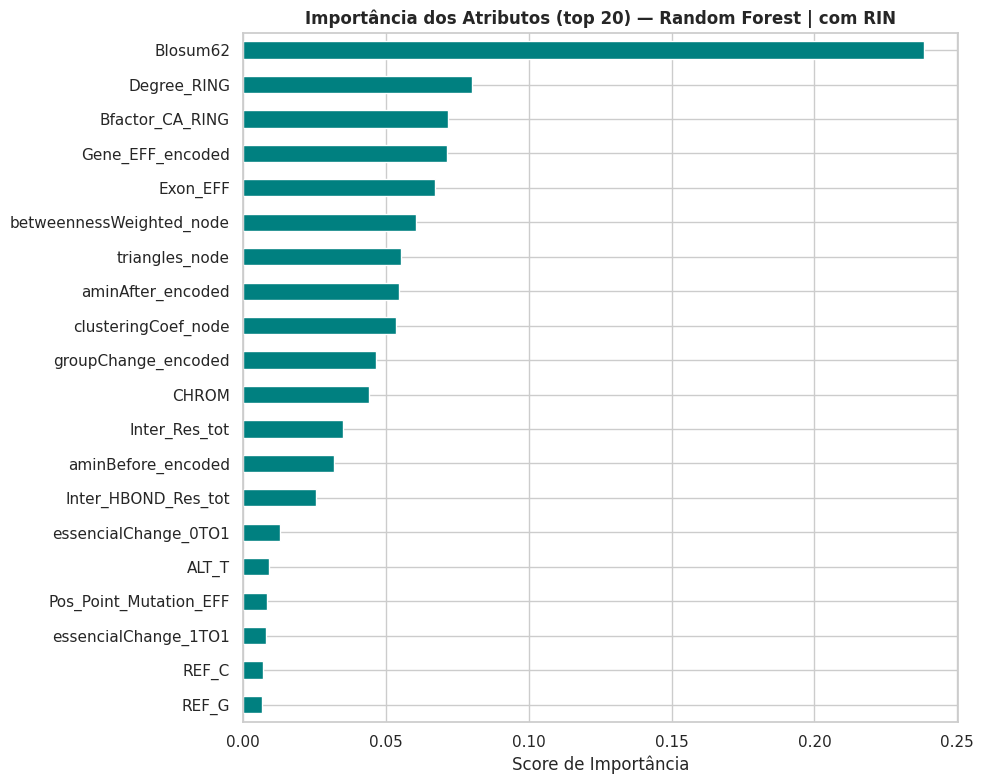

In [15]:
plot_feature_importance(rf_com, X_train_com.columns, 'Random Forest | com RIN', top_n=20)


## 4.2 XGBoost — Com RIN

In [16]:
xgb_com = RandomizedSearchCV(
    estimator     = XGBClassifier(
        eval_metric  = 'logloss',
        use_label_encoder = False,
        random_state = 42,
        verbosity    = 0,
    ),
    param_distributions = param_xgb,
    n_iter        = N_ITER,
    cv            = cv_strat,
    scoring       = scorers,
    refit         = REFIT,
    return_train_score = True,
    n_jobs        = -1,
    random_state  = SEED,
    verbose       = 1,
)

xgb_com.fit(X_train_com, y_train_com)

print('\n── Melhores Hiperparâmetros (XGBoost | com RIN) ──')
for k, v in xgb_com.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nMelhor Accuracy (CV treino): {xgb_com.best_score_:.4f}')


Fitting 10 folds for each of 100 candidates, totalling 1000 fits

── Melhores Hiperparâmetros (XGBoost | com RIN) ──
  colsample_bytree: 0.7034791796600751
  gamma: 0.32906258329593147
  learning_rate: 0.028449593551861156
  max_depth: 4
  min_child_weight: 7
  n_estimators: 188
  reg_alpha: 0.505473015440467
  reg_lambda: 2.197296782886614
  subsample: 0.9238265489795074

Melhor Accuracy (CV treino): 0.6518


In [17]:
res_xgb_com = avaliar_modelo('XGB — com RIN', xgb_com, X_test_com, y_test_com)
print('── Métricas na base de TESTE (XGBoost | com RIN) ──')
for k, v in res_xgb_com.items():
    if not k.startswith('_'):
        print(f'  {k}: {v}')


── Métricas na base de TESTE (XGBoost | com RIN) ──
  Modelo: XGB — com RIN
  Acc. (%): 71.51
  TNR (%): 75.58
  NPV (%): 68.42
  TPR (%): 67.74
  PPV (%): 75.0
  ROC-AUC: 0.7611
  F1-Score (%): 71.19


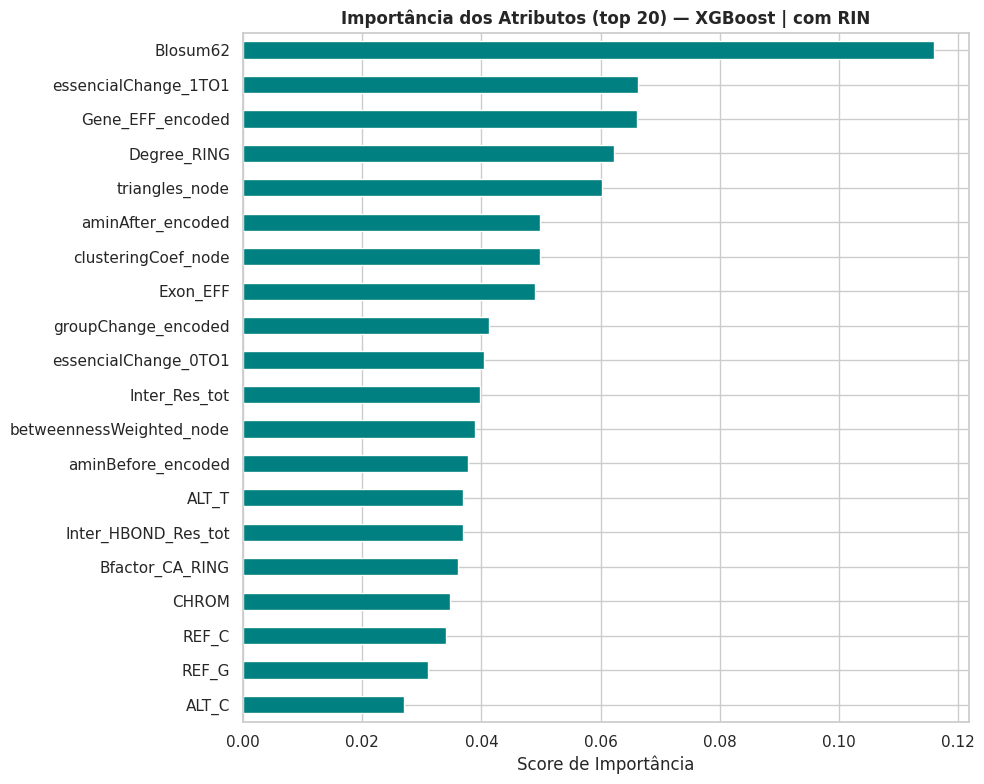

In [18]:
plot_feature_importance(xgb_com, X_train_com.columns, 'XGBoost | com RIN', top_n=20)


## 4.3 Resultados Consolidados — Com RIN

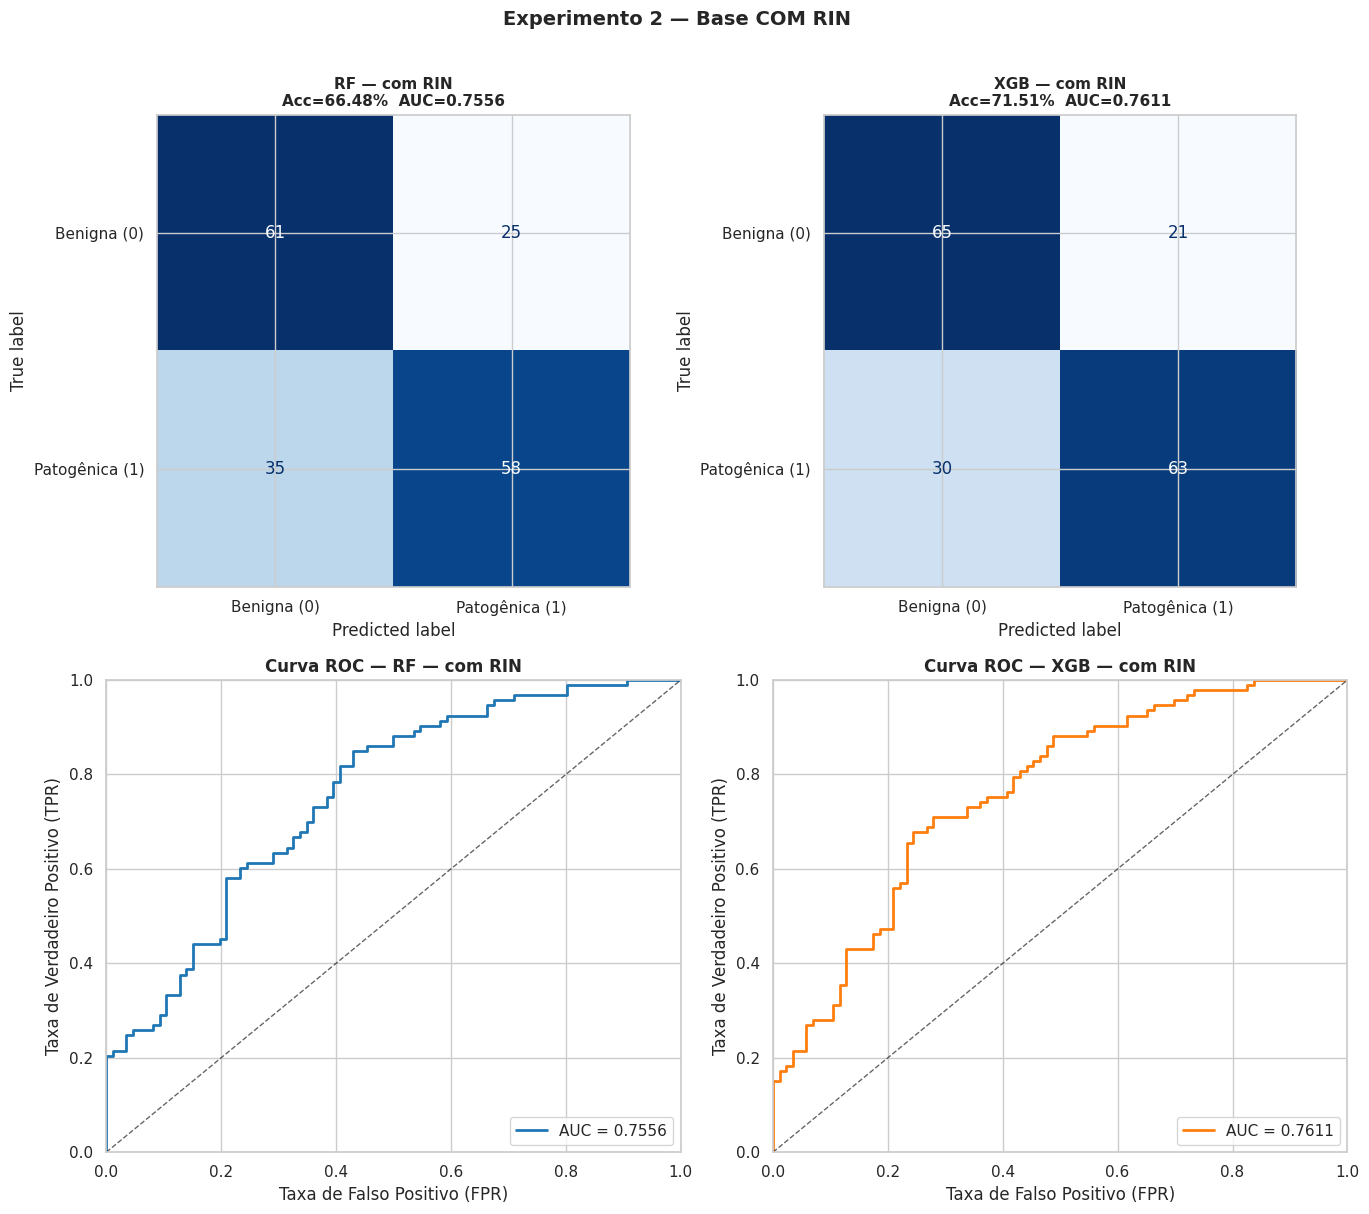


── Tabela de Métricas — Experimento 2 (COM RIN) ──


,Acc. (%),TNR (%),NPV (%),TPR (%),PPV (%),ROC-AUC,F1-Score (%)
Modelo,,,,,,,
RF — com RIN,66.48,70.93,63.54,62.37,69.88,0.76,65.91
XGB — com RIN,71.51,75.58,68.42,67.74,75.00,0.76,71.19


In [19]:
resultados_com = [res_rf_com, res_xgb_com]

plot_resultados(
    resultados_com,
    X_test_com, y_test_com,
    'Experimento 2 — Base COM RIN'
)

print('\n── Tabela de Métricas — Experimento 2 (COM RIN) ──')
display(tabela_metricas(resultados_com))


# 5. Comparação Geral — Sem RIN vs Com RIN

Tabela unificada e gráfico comparativo de todas as métricas.


In [20]:
todos = [res_rf_sem, res_xgb_sem, res_rf_com, res_xgb_com]
cols  = ['Modelo', 'Acc. (%)', 'TNR (%)', 'NPV (%)',
         'TPR (%)', 'PPV (%)', 'ROC-AUC', 'F1-Score (%)']

df_comp = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')}
    for r in todos
])[cols].set_index('Modelo')

print('── Comparação Geral ──────────────────────────────────────────────────')
display(df_comp.style.highlight_max(axis=0, color='#d4edda').format(precision=2))


── Comparação Geral ──────────────────────────────────────────────────


,Acc. (%),TNR (%),NPV (%),TPR (%),PPV (%),ROC-AUC,F1-Score (%)
Modelo,,,,,,,
RF — sem RIN,67.60,66.28,66.28,68.82,68.82,0.77,68.82
XGB — sem RIN,63.13,63.95,61.11,62.37,65.17,0.74,63.74
RF — com RIN,66.48,70.93,63.54,62.37,69.88,0.76,65.91
XGB — com RIN,71.51,75.58,68.42,67.74,75.00,0.76,71.19


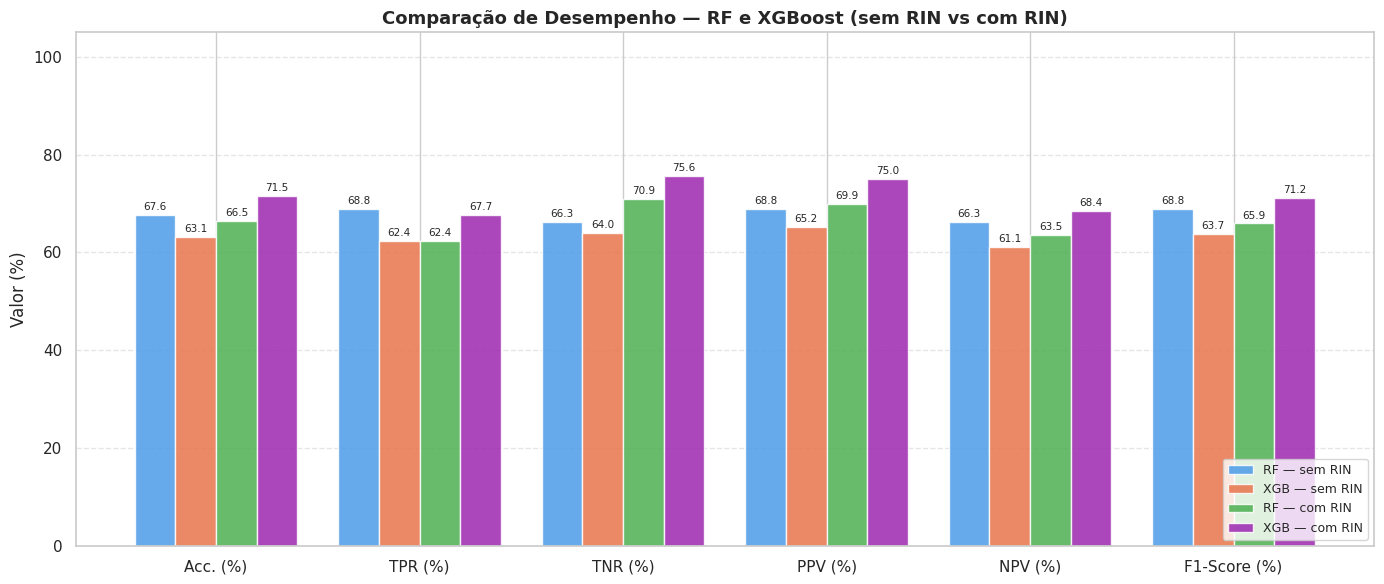

In [21]:
# ── Gráfico de barras comparativo ────────────────────────────────────────────
metricas_plot = ['Acc. (%)', 'TPR (%)', 'TNR (%)', 'PPV (%)', 'NPV (%)', 'F1-Score (%)']
df_plot = df_comp[metricas_plot].copy()

x     = np.arange(len(metricas_plot))
width = 0.2
cores = ['#4C9BE8', '#E8744C', '#4CAF50', '#9C27B0']
modelos = df_plot.index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
for i, (modelo, cor) in enumerate(zip(modelos, cores)):
    offset = (i - len(modelos) / 2 + 0.5) * width
    bars = ax.bar(x + offset, df_plot.loc[modelo], width,
                  label=modelo, color=cor, alpha=0.85, edgecolor='white')
    ax.bar_label(bars, fmt='%.1f', fontsize=7.5, padding=2)

ax.set_xticks(x)
ax.set_xticklabels(metricas_plot, fontsize=11)
ax.set_ylabel('Valor (%)', fontsize=12)
ax.set_title('Comparação de Desempenho — RF e XGBoost (sem RIN vs com RIN)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_ylim(0, 105)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


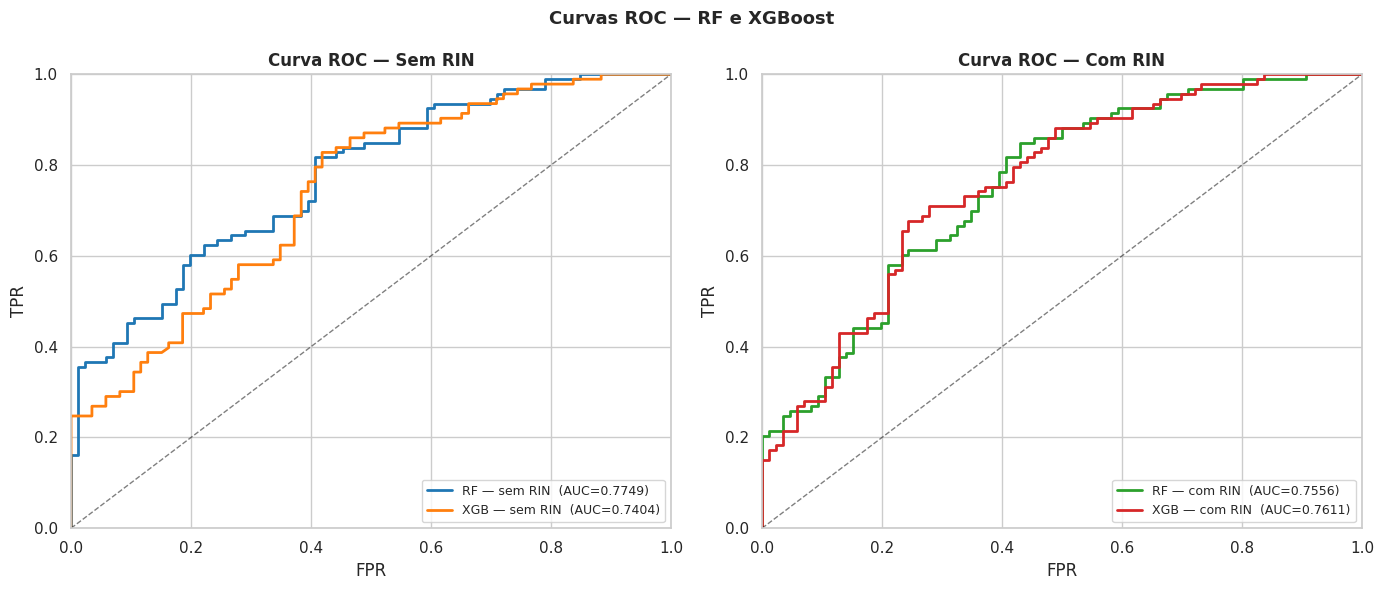

In [22]:
# ── Curvas ROC sobrepostas ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
labels_exp = [
    ('RF — sem RIN', res_rf_sem, y_test_sem),
    ('XGB — sem RIN', res_xgb_sem, y_test_sem),
    ('RF — com RIN', res_rf_com, y_test_com),
    ('XGB — com RIN', res_xgb_com, y_test_com),
]
cores_roc = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for ax, titulo_ax, filtro in [
    (axes[0], 'Sem RIN', 'sem'),
    (axes[1], 'Com RIN', 'com'),
]:
    for (nome, res, y_t), cor in zip(labels_exp, cores_roc):
        if filtro in nome.lower():
            from sklearn.metrics import roc_curve
            fpr, tpr_vals, _ = roc_curve(y_t, res['_y_proba'])
            ax.plot(fpr, tpr_vals, color=cor, lw=2,
                    label=f'{nome}  (AUC={res["ROC-AUC"]:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.set_title(f'Curva ROC — {titulo_ax}', fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.suptitle('Curvas ROC — RF e XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [23]:
# ── Resumo final impresso ─────────────────────────────────────────────────────
print('=' * 70)
print('RESUMO FINAL')
print('=' * 70)
for res in todos:
    print(f"\n{res['Modelo']}")
    print(f"  Acc={res['Acc. (%)']:.2f}%  TPR={res['TPR (%)']:.2f}%  "          f"TNR={res['TNR (%)']:.2f}%  AUC={res['ROC-AUC']:.4f}  "          f"F1={res['F1-Score (%)']:.2f}%")

# Melhor modelo por AUC
melhor = max(todos, key=lambda r: r['ROC-AUC'])
print(f"\n→ Melhor ROC-AUC: {melhor['Modelo']} ({melhor['ROC-AUC']:.4f})")
melhor_acc = max(todos, key=lambda r: r['Acc. (%)'])
print(f"→ Melhor Acurácia: {melhor_acc['Modelo']} ({melhor_acc['Acc. (%)']:.2f}%)")


RESUMO FINAL

RF — sem RIN
  Acc=67.60%  TPR=68.82%  TNR=66.28%  AUC=0.7749  F1=68.82%

XGB — sem RIN
  Acc=63.13%  TPR=62.37%  TNR=63.95%  AUC=0.7404  F1=63.74%

RF — com RIN
  Acc=66.48%  TPR=62.37%  TNR=70.93%  AUC=0.7556  F1=65.91%

XGB — com RIN
  Acc=71.51%  TPR=67.74%  TNR=75.58%  AUC=0.7611  F1=71.19%

→ Melhor ROC-AUC: RF — sem RIN (0.7749)
→ Melhor Acurácia: XGB — com RIN (71.51%)
